# DATABASE CREATION

Goal: build a small database-style layer from `metadata_all.csv`, `sequencing_runs_paths_ERDA.csv`, and `read_count.csv`.

The most important final object is `FP_analysis_selection`: one row per FASTQ pair. It inherits stable metadata from lookup tables using explicit two-letter object codes.

Naming rules used here:

- Every database object/table starts with a two-letter code.
- Every object-owned column starts with the same two-letter code.
- Foreign keys keep the referenced object's code, for example `LY_id`, `SP_id`, `SR_id`.
- `metadata_all.csv` is treated as an export/source view, not as the database itself.


# LOAD VARIABLES, DFs AND FUNCTIONS

In [27]:
import ast
import re
from pathlib import Path

import pandas as pd
import numpy as np

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    plt = None
    FancyArrowPatch = None

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 120)


In [28]:
NOTEBOOK_DIR = Path.cwd()
MICROBIOMICS_DIR = NOTEBOOK_DIR.parent

metadata_all_file = NOTEBOOK_DIR / "metadata_all.csv"
sequencing_runs_file = MICROBIOMICS_DIR / "sequencing_runs_paths_ERDA.csv"
read_count_file = MICROBIOMICS_DIR / "read_count.csv"

database_output_dir = NOTEBOOK_DIR / "database_tables"
shared_database_output_dir = MICROBIOMICS_DIR / "DB"


In [29]:
def normalize_read_count_path(path):
    path = str(path).strip()
    if path.startswith("./"):
        return path
    marker = "/sequencing_runs/"
    if marker in path:
        return "./" + path.split(marker, 1)[1].lstrip("/")
    return "./" + path.lstrip("/")


def filename_only(path):
    if pd.isna(path):
        return pd.NA
    return Path(str(path)).name


def parse_fastq_value(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value or value.lower() == "nan":
        return []
    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(x) for x in parsed if pd.notna(x)]
        except Exception:
            return [value]
    return [value]


def clean_token(value):
    if pd.isna(value):
        return "UNKNOWN"
    value = str(value).strip()
    if not value or value.lower() == "nan":
        return "UNKNOWN"
    value = re.sub(r"[^A-Za-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value or "UNKNOWN"


def ensure_prefix(value, prefix):
    token = clean_token(value)
    if token.startswith(prefix + "_"):
        return token
    return f"{prefix}_{token}"


def get_col(df, col, default=pd.NA):
    if col in df.columns:
        return df[col]
    return pd.Series(default, index=df.index, dtype="object")


def first_non_null(values):
    values = values.dropna()
    values = values[values.astype(str).str.lower() != "nan"]
    values = values[values.astype(str).str.strip() != ""]
    if len(values) == 0:
        return pd.NA
    return values.iloc[0]


def unique_join(values, max_values=12):
    values = values.dropna().astype(str)
    values = values[~values.str.lower().eq("nan")]
    values = values[values.str.strip() != ""]
    seen = []
    for value in values:
        if value not in seen:
            seen.append(value)
    if len(seen) > max_values:
        return " | ".join(seen[:max_values]) + f" | ... ({len(seen)} values)"
    return " | ".join(seen) if seen else pd.NA


def make_relative_fastq_path(SR_id, fastq_value):
    filename = filename_only(fastq_value)
    if pd.isna(filename):
        return pd.NA
    return f"./{SR_id}/{filename}"


# LOAD CURRENT EXPORTS

In [30]:
metadata_all = pd.read_csv(metadata_all_file)
sequencing_runs = pd.read_csv(sequencing_runs_file)
read_count = pd.read_csv(read_count_file, sep="	")

read_count["Path"] = read_count["Path"].map(normalize_read_count_path)
read_count["Reads"] = pd.to_numeric(read_count["Reads"], errors="coerce")

if "is_rerun" in metadata_all.columns:
    metadata_all["is_rerun"] = metadata_all["is_rerun"].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)
else:
    metadata_all["is_rerun"] = False

if "sequencing_run" not in metadata_all.columns:
    metadata_all["sequencing_run"] = metadata_all["run_ID"]

print("metadata_all", metadata_all.shape)
print("sequencing_runs", sequencing_runs.shape)
print("read_count", read_count.shape)


metadata_all (6525, 115)
sequencing_runs (26, 3)
read_count (17350, 2)


# OBJECT REGISTRY

In [ ]:
OB_object_registry = pd.DataFrame(
    [
        ["OB", "OB_object_registry", "OB_code", "Object registry and naming rules"],
        ["LY", "LY_location_year", "LY_id", "Location/year context"],
        ["SP", "SP_sample_plot", "SP_id", "Sample plot identity"],
        ["LS", "LS_location_sample_plot", "LS_id", "Location-year/sample-plot bridge"],
        ["BS", "BS_biological_sample", "BS_id", "Biological sample or biological control material"],
        ["EX", "EX_extraction", "EX_id", "DNA extraction"],
        ["LP", "LP_library_preparation", "LP_id", "Prepared library"],
        ["SR", "SR_sequencing_run", "SR_id", "Sequencing run/folder"],
        ["SA", "SA_sequencing_attempt", "SA_id", "A library sequenced in a run"],
        ["FP", "FP_fastq_pair", "FP_id", "One R1/R2 FASTQ pair"],
        ["FF", "FF_fastq_file", "FF_id", "One FASTQ file"],
        ["RC", "RC_read_count", "RC_id", "Read count for one FASTQ file"],
    ],
    columns=["OB_code", "OB_table", "OB_primary_key", "OB_description"],
)
OB_object_registry


,OB_code,OB_table,OB_primary_key,OB_description
0,OB,OB_object_registry,OB_code,Object registry and naming rules
1,LY,LY_location_year,LY_id,Location/year context
2,SP,SP_sample_plot,SP_id,Sample plot identity
3,LS,LS_location_sample_plot,LS_id,Location-year/sample-plot bridge
4,BS,BS_biological_sample,BS_id,Biological sample or biological control material
5,EX,EX_extraction,EX_id,DNA extraction
6,LP,LP_library_preparation,LP_id,Prepared library
7,SR,SR_sequencing_run,SR_id,Sequencing run/folder
8,SA,SA_sequencing_attempt,SA_id,A library sequenced in a run
9,FP,FP_fastq_pair,FP_id,One R1/R2 FASTQ pair


# DB RELATIONSHIP DRAWING

```mermaid
erDiagram
    LY_location_year ||--o{ LS_location_sample_plot : has
    SP_sample_plot ||--o{ LS_location_sample_plot : appears_in
    LS_location_sample_plot ||--o{ BS_biological_sample : has
    BS_biological_sample ||--o{ EX_extraction : has
    EX_extraction ||--o{ LP_library_preparation : has
    LP_library_preparation ||--o{ SA_sequencing_attempt : sequenced_as
    SR_sequencing_run ||--o{ SA_sequencing_attempt : contains
    SA_sequencing_attempt ||--o{ FP_fastq_pair : produces
    FP_fastq_pair ||--o{ FF_fastq_file : contains
    FF_fastq_file ||--o| RC_read_count : counted_by
```


# CREATE STABLE IDS

In [32]:
db = metadata_all.copy()

# Stable context ids. Existing generated columns are preferred where available.
db["LY_id"] = get_col(db, "LY").map(lambda x: ensure_prefix(x, "LY"))
db["SP_id"] = get_col(db, "SP").map(lambda x: ensure_prefix(x, "SP"))

fallback_LS = db["LY_id"].astype(str) + "__" + db["SP_id"].astype(str)
db["LS_id"] = get_col(db, "LY_SP").fillna(fallback_LS).map(lambda x: ensure_prefix(x, "LS") if not str(x).startswith("LY_") else "LS_" + clean_token(x))

bs_source = get_col(db, "BS").fillna(get_col(db, "LY_SP_BS")).fillna(get_col(db, "bio_sample_ID"))
db["BS_id"] = bs_source.map(lambda x: ensure_prefix(x, "BS"))

ex_source = get_col(db, "LY_SP_BS_EX").fillna(get_col(db, "EX"))
ex_source = ex_source.fillna(db["BS_id"].astype(str) + "__" + get_col(db, "DNA_ext_date").astype(str))
db["EX_id"] = ex_source.map(lambda x: ensure_prefix(x, "EX"))

lp_source = get_col(db, "LY_SP_BS_EX_LP").fillna(get_col(db, "LP"))
lp_fallback = (
    db["EX_id"].astype(str)
    + "__" + get_col(db, "LIBRARY_PREPARATION").astype(str)
    + "__" + get_col(db, "amplicon").astype(str)
    + "__" + get_col(db, "index_pair").astype(str)
    + "__" + get_col(db, "lib_plate_number").astype(str)
    + "__" + get_col(db, "plate_position").astype(str)
)
db["LP_id"] = lp_source.fillna(lp_fallback).map(lambda x: ensure_prefix(x, "LP"))

db["SR_id"] = get_col(db, "run_ID").map(lambda x: clean_token(x))

sa_base = (
    db["SR_id"].astype(str)
    + "__" + get_col(db, "seq_sample_ID").astype(str).map(clean_token)
    + "__" + get_col(db, "source").astype(str).map(clean_token)
)
sa_order = sa_base.groupby(sa_base).cumcount() + 1
db["SA_id"] = [f"SA_{base}" if n == 1 else f"SA_{base}__D{n}" for base, n in zip(sa_base, sa_order)]
db["SA_duplicate_number"] = sa_order

id_cols = ["LY_id", "SP_id", "LS_id", "BS_id", "EX_id", "LP_id", "SR_id", "SA_id", "SA_duplicate_number"]
db[id_cols].head()


,LY_id,SP_id,LS_id,BS_id,EX_id,LP_id,SR_id,SA_id,SA_duplicate_number
0,LY_X_0000,SP_000,LS_LY_X_0000_SP_000,BS_ZYMCTL_X_0,EX_LY_X_0000_SP_000_BS_ZYMCTL_X_0_EX_000000,LP_LY_X_0000_SP_000_BS_ZYMCTL_X_0_EX_000000_LP_230428_ITS,seq230710_GW4I8,SA_seq230710_GW4I8__T_2020_ITS_c_pos__2020_washed_amplicon,1
1,LY_T_2020,SP_024,LS_LY_T_2020_SP_024,BS_200603_W_1,EX_LY_T_2020_SP_024_BS_200603_W_1_EX_210109,LP_LY_T_2020_SP_024_BS_200603_W_1_EX_210109_LP_230428_ITS,seq230710_GW4I8,SA_seq230710_GW4I8__T_2020_ITS_c_24__2020_washed_amplicon,1
2,LY_T_2020,SP_023,LS_LY_T_2020_SP_023,BS_200603_W_1,EX_LY_T_2020_SP_023_BS_200603_W_1_EX_210109,LP_LY_T_2020_SP_023_BS_200603_W_1_EX_210109_LP_230428_ITS,seq230710_GW4I8,SA_seq230710_GW4I8__T_2020_ITS_c_23__2020_washed_amplicon,1
3,LY_T_2020,SP_022,LS_LY_T_2020_SP_022,BS_200603_W_1,EX_LY_T_2020_SP_022_BS_200603_W_1_EX_210109,LP_LY_T_2020_SP_022_BS_200603_W_1_EX_210109_LP_230428_ITS,seq230710_GW4I8,SA_seq230710_GW4I8__T_2020_ITS_c_22__2020_washed_amplicon,1
4,LY_T_2020,SP_021,LS_LY_T_2020_SP_021,BS_200603_W_1,EX_LY_T_2020_SP_021_BS_200603_W_1_EX_210109,LP_LY_T_2020_SP_021_BS_200603_W_1_EX_210109_LP_230428_ITS,seq230710_GW4I8,SA_seq230710_GW4I8__T_2020_ITS_c_21__2020_washed_amplicon,1


# LOOKUP TABLES

In [33]:
LY_location_year = (
    db.assign(
        LY_year=get_col(db, "YEAR"),
        LY_location=get_col(db, "location").fillna(get_col(db, "SP_location")),
    )
    .groupby("LY_id", dropna=False)
    .agg(
        LY_year=("LY_year", unique_join),
        LY_location=("LY_location", unique_join),
        LY_source_values=("LY", unique_join),
        LY_row_count=("SA_id", "size"),
    )
    .reset_index()
)

SP_sample_plot = (
    db.assign(
        SP_sample_number=get_col(db, "SP_sample_number").fillna(get_col(db, "sample_number")),
        SP_plot=get_col(db, "SP_plot").fillna(get_col(db, "plot")),
    )
    .groupby("SP_id", dropna=False)
    .agg(
        SP_sample_number=("SP_sample_number", unique_join),
        SP_plot=("SP_plot", unique_join),
        SP_source_values=("SP", unique_join),
        SP_row_count=("SA_id", "size"),
    )
    .reset_index()
)

LS_location_sample_plot = (
    db.assign(
        LS_block=get_col(db, "SP_block").fillna(get_col(db, "block")),
        LS_plot=get_col(db, "SP_plot").fillna(get_col(db, "plot")),
        LS_subplot=get_col(db, "SP_subplot").fillna(get_col(db, "subplot")),
        LS_cultivar=get_col(db, "SP_cultivar").fillna(get_col(db, "cultivar")).fillna(get_col(db, "Cultivar")),
        LS_spray=get_col(db, "SP_spray").fillna(get_col(db, "spray")).fillna(get_col(db, "spray_fungicide")),
        LS_fertilizer=get_col(db, "SP_fertilizer").fillna(get_col(db, "fertilizer")).fillna(get_col(db, "fertiliser")),
        LS_density=get_col(db, "SP_density").fillna(get_col(db, "density")),
        LS_location=get_col(db, "SP_location").fillna(get_col(db, "location")),
    )
    .groupby("LS_id", dropna=False)
    .agg(
        LY_id=("LY_id", first_non_null),
        SP_id=("SP_id", first_non_null),
        LS_block=("LS_block", unique_join),
        LS_plot=("LS_plot", unique_join),
        LS_subplot=("LS_subplot", unique_join),
        LS_cultivar=("LS_cultivar", unique_join),
        LS_spray=("LS_spray", unique_join),
        LS_fertilizer=("LS_fertilizer", unique_join),
        LS_density=("LS_density", unique_join),
        LS_location=("LS_location", unique_join),
        LS_row_count=("SA_id", "size"),
    )
    .reset_index()
)

BS_biological_sample = (
    db.assign(
        BS_original_sample_id=get_col(db, "bio_sample_ID"),
        BS_sample_date=get_col(db, "sample_date"),
        BS_sample_type=get_col(db, "sample_type"),
        BS_sample_number=get_col(db, "sample_number"),
        BS_leaf_protocol=get_col(db, "LEAF_PROTOCOL"),
        BS_note=get_col(db, "note"),
    )
    .groupby("BS_id", dropna=False)
    .agg(
        LS_id=("LS_id", first_non_null),
        LY_id=("LY_id", first_non_null),
        SP_id=("SP_id", first_non_null),
        BS_original_sample_id=("BS_original_sample_id", unique_join),
        BS_sample_date=("BS_sample_date", unique_join),
        BS_sample_type=("BS_sample_type", unique_join),
        BS_sample_number=("BS_sample_number", unique_join),
        BS_leaf_protocol=("BS_leaf_protocol", unique_join),
        BS_note=("BS_note", unique_join),
        BS_row_count=("SA_id", "size"),
    )
    .reset_index()
)

EX_extraction = (
    db.assign(
        EX_date=get_col(db, "DNA_ext_date"),
        EX_plate=get_col(db, "DNA_plate_number"),
        EX_dna_conc=get_col(db, "DNA_conc_plate").fillna(get_col(db, "DNA_conc_individual")),
    )
    .groupby("EX_id", dropna=False)
    .agg(
        BS_id=("BS_id", first_non_null),
        EX_date=("EX_date", unique_join),
        EX_plate=("EX_plate", unique_join),
        EX_dna_conc=("EX_dna_conc", unique_join),
        EX_row_count=("SA_id", "size"),
    )
    .reset_index()
)

LP_library_preparation = (
    db.assign(
        LP_library_preparation=get_col(db, "LIBRARY_PREPARATION"),
        LP_amplicon=get_col(db, "amplicon"),
        LP_lib_prep=get_col(db, "lib_prep"),
        LP_plate_number=get_col(db, "lib_plate_number"),
        LP_plate_position=get_col(db, "plate_position"),
        LP_index_pair=get_col(db, "index_pair"),
        LP_s5_index=get_col(db, "S5_index"),
        LP_n7_index=get_col(db, "N7_index"),
        LP_pcr1_date=get_col(db, "PCR1_date"),
        LP_pcr2_date=get_col(db, "PCR2_date"),
    )
    .groupby("LP_id", dropna=False)
    .agg(
        EX_id=("EX_id", first_non_null),
        BS_id=("BS_id", first_non_null),
        LP_library_preparation=("LP_library_preparation", unique_join),
        LP_amplicon=("LP_amplicon", unique_join),
        LP_lib_prep=("LP_lib_prep", unique_join),
        LP_plate_number=("LP_plate_number", unique_join),
        LP_plate_position=("LP_plate_position", unique_join),
        LP_index_pair=("LP_index_pair", unique_join),
        LP_s5_index=("LP_s5_index", unique_join),
        LP_n7_index=("LP_n7_index", unique_join),
        LP_pcr1_date=("LP_pcr1_date", unique_join),
        LP_pcr2_date=("LP_pcr2_date", unique_join),
        LP_row_count=("SA_id", "size"),
    )
    .reset_index()
)

LY_location_year.head(), SP_sample_plot.head(), LS_location_sample_plot.head(), BS_biological_sample.head(), EX_extraction.head(), LP_library_preparation.head()


(       LY_id         LY_year LY_location LY_source_values  LY_row_count
 0  LY_A_2022  2022 | control           A        LY_A_2022          1026
 1  LY_H_2022            2022           H        LY_H_2022           577
 2  LY_L_2022            2022           L        LY_L_2022           391
 3  LY_R_2022            2022           R        LY_R_2022          1569
 4  LY_S_2022            2022           S        LY_S_2022           411,
     SP_id SP_sample_number  SP_plot SP_source_values  SP_row_count
 0  SP_000             <NA>     <NA>           SP_000           166
 1  SP_001          1.0 | 1  1.0 | 1           SP_001           178
 2  SP_002          2.0 | 2  2.0 | 2           SP_002           169
 3  SP_003          3.0 | 3  3.0 | 3           SP_003           254
 4  SP_004          4.0 | 4  4.0 | 4           SP_004           143,
                  LS_id      LY_id   SP_id LS_block LS_plot LS_subplot  \
 0  LS_LY_A_2022_SP_001  LY_A_2022  SP_001      1.0     1.0       <NA>   
 1  

# SEQUENCING RUN, ATTEMPT, FASTQ PAIR, FILE, READ COUNT

In [34]:
SR_from_paths = sequencing_runs.rename(
    columns={"dir_name": "SR_id", "full_path": "SR_full_path", "Unnamed: 0": "SR_order"}
).copy()
SR_from_paths["SR_run_name"] = SR_from_paths["SR_id"]
SR_from_paths["SR_relative_path"] = "./" + SR_from_paths["SR_id"].astype(str)
SR_from_metadata = pd.DataFrame({"SR_id": sorted(db["SR_id"].dropna().astype(str).unique())})

SR_sequencing_run = SR_from_metadata.merge(SR_from_paths, on="SR_id", how="left")
SR_sequencing_run["SR_in_path_table"] = SR_sequencing_run["SR_full_path"].notna()
SR_sequencing_run = SR_sequencing_run[["SR_id", "SR_run_name", "SR_relative_path", "SR_full_path", "SR_order", "SR_in_path_table"]]

# Dea-style purpose flags, stored at sequencing-attempt level.
SA_run_name = db["SR_id"].astype("string").str.extract(r"_([^_]*)$", expand=False).fillna(db["SR_id"].astype("string"))
SA_first_forward_fq = get_col(db, "forward_fq").map(lambda value: filename_only(parse_fastq_value(value)[0]) if parse_fastq_value(value) else pd.NA)
SA_purpose_rowname = pd.Series(pd.NA, index=db.index, dtype="object")
SA_purpose_rowname.loc[SA_first_forward_fq.notna()] = db.loc[SA_first_forward_fq.notna(), "SR_id"].astype(str) + "/" + SA_first_forward_fq.loc[SA_first_forward_fq.notna()].astype(str)
SA_duplicate_rownames = set(SA_purpose_rowname.dropna().value_counts().loc[lambda counts: counts > 1].index)
SA_suggested_seq_sample_ID = get_col(db, "suggested_correct_seq_sample_ID").astype("string")
SA_suggested_contains_run_name = pd.Series(
    [False if pd.isna(sample_id) or pd.isna(run_name) else str(run_name) in str(sample_id) for sample_id, run_name in zip(SA_suggested_seq_sample_ID, SA_run_name)],
    index=db.index,
)
SA_is_lib_control = get_col(db, "LY").astype("string").str.contains("0000", na=False)
db["SA_is_seq_control"] = SA_suggested_contains_run_name | SA_purpose_rowname.isin(SA_duplicate_rownames)
db["SA_is_sample"] = ~SA_is_lib_control & ~SA_suggested_contains_run_name
db["SA_is_lib_control"] = SA_is_lib_control
db["SA_purpose"] = np.select(
    [
        db["SA_is_sample"] & db["SA_is_seq_control"],
        db["SA_is_sample"],
        db["SA_is_seq_control"],
        db["SA_is_lib_control"],
    ],
    ["sample_and_seq_control", "sample", "seq_control", "library_control"],
    default="unclassified",
)

SA_sequencing_attempt = db[[
    "SA_id", "LP_id", "SR_id", "BS_id", "EX_id", "LS_id", "LY_id", "SP_id", "source", "seq_sample_ID", "is_rerun", "sequencing_run",
    "SA_is_sample", "SA_is_seq_control", "SA_is_lib_control", "SA_purpose", "SA_duplicate_number"
]].rename(columns={
    "source": "SA_source",
    "seq_sample_ID": "SA_seq_sample_ID",
    "is_rerun": "SA_is_rerun",
    "sequencing_run": "SA_sequencing_run",
}).copy()

RC_read_count = read_count.copy()
RC_read_count["RC_path"] = RC_read_count["Path"].map(normalize_read_count_path)
RC_read_count["SR_id"] = RC_read_count["RC_path"].str.split("/").str[1]
RC_read_count["RC_filename"] = RC_read_count["RC_path"].map(filename_only)
RC_read_count["RC_read_direction"] = RC_read_count["RC_filename"].str.extract(r"_(R[12])_")[0]
RC_read_count["RC_reads"] = RC_read_count["Reads"]
RC_read_count["RC_id"] = "RC_" + RC_read_count["RC_path"].map(clean_token)
RC_read_count = RC_read_count[["RC_id", "SR_id", "RC_path", "RC_filename", "RC_read_direction", "RC_reads"]]
RC_reads_by_path = RC_read_count.drop_duplicates("RC_path").set_index("RC_path")["RC_reads"]

fp_rows = []
for row_number, row in db.iterrows():
    forward_files = parse_fastq_value(row.get("forward_fq"))
    reverse_files = parse_fastq_value(row.get("reverse_fq"))
    pair_count = max(len(forward_files), len(reverse_files))
    if pair_count == 0:
        pair_count = 1
    for pair_number in range(pair_count):
        forward_value = forward_files[pair_number] if pair_number < len(forward_files) else pd.NA
        reverse_value = reverse_files[pair_number] if pair_number < len(reverse_files) else pd.NA
        forward_filename = filename_only(forward_value)
        reverse_filename = filename_only(reverse_value)
        forward_path = make_relative_fastq_path(row["SR_id"], forward_value) if pd.notna(forward_filename) else pd.NA
        reverse_path = make_relative_fastq_path(row["SR_id"], reverse_value) if pd.notna(reverse_filename) else pd.NA
        fp_id = f"FP_{clean_token(row['SA_id'])}__P{pair_number + 1:02d}"
        fp_rows.append(
            {
                "FP_id": fp_id,
                "SA_id": row["SA_id"],
                "SR_id": row["SR_id"],
                "LP_id": row["LP_id"],
                "FP_source": row["source"],
                "FP_rowname": f"{row['SR_id']}/{forward_filename}" if pd.notna(forward_filename) else pd.NA,
                "FP_pair_number": pair_number + 1,
                "FP_forward_fq": forward_filename,
                "FP_reverse_fq": reverse_filename,
                "FP_forward_path": forward_path,
                "FP_reverse_path": reverse_path,
                "FP_forward_reads": RC_reads_by_path.get(forward_path, pd.NA),
                "FP_reverse_reads": RC_reads_by_path.get(reverse_path, pd.NA),
            }
        )

FP_fastq_pair = pd.DataFrame(fp_rows)
FP_fastq_pair["FP_include_control_crushed_amplicon"] = False
FP_fastq_pair["FP_control_crushed_amplicon_SA_id"] = pd.NA

# If the same physical FASTQ pair appears as both 2022_crushed_amplicon and
# control_crushed_amplicon, keep the 2022 row and annotate it with the control source.
physical_pair_cols = ["SR_id", "FP_forward_path", "FP_reverse_path"]
complete_pair_mask = FP_fastq_pair["FP_forward_path"].notna() & FP_fastq_pair["FP_reverse_path"].notna()
source_sets_by_pair = (
    FP_fastq_pair.loc[complete_pair_mask]
    .groupby(physical_pair_cols)["FP_source"]
    .agg(lambda values: set(values.dropna().astype(str)))
)
control_collision_keys = source_sets_by_pair[
    source_sets_by_pair.map(lambda sources: {"2022_crushed_amplicon", "control_crushed_amplicon"}.issubset(sources))
].index
FP_control_collision_count = len(control_collision_keys)
FP_control_collision_dropped_rows = 0

if FP_control_collision_count:
    control_collision_table = pd.DataFrame(list(control_collision_keys), columns=physical_pair_cols)
    control_sa_by_pair = (
        FP_fastq_pair.merge(control_collision_table, on=physical_pair_cols, how="inner")
        .loc[lambda df: df["FP_source"].eq("control_crushed_amplicon")]
        .groupby(physical_pair_cols)["SA_id"]
        .agg(unique_join)
        .reset_index(name="FP_control_crushed_amplicon_SA_id_from_control")
    )
    FP_fastq_pair = FP_fastq_pair.merge(control_sa_by_pair, on=physical_pair_cols, how="left")
    FP_fastq_pair["FP_control_crushed_amplicon_SA_id"] = FP_fastq_pair[
        "FP_control_crushed_amplicon_SA_id_from_control"
    ].combine_first(FP_fastq_pair["FP_control_crushed_amplicon_SA_id"])
    FP_fastq_pair = FP_fastq_pair.drop(columns=["FP_control_crushed_amplicon_SA_id_from_control"])
    FP_fastq_pair = FP_fastq_pair.merge(
        control_collision_table.assign(FP_has_control_collision=True),
        on=physical_pair_cols,
        how="left",
    )
    FP_fastq_pair["FP_has_control_collision"] = FP_fastq_pair["FP_has_control_collision"].fillna(False)
    drop_control_collision_mask = FP_fastq_pair["FP_has_control_collision"] & FP_fastq_pair["FP_source"].eq("control_crushed_amplicon")
    FP_control_collision_dropped_rows = int(drop_control_collision_mask.sum())
    FP_fastq_pair = FP_fastq_pair.loc[~drop_control_collision_mask].copy()
    FP_fastq_pair["FP_include_control_crushed_amplicon"] = (
        FP_fastq_pair["FP_source"].eq("2022_crushed_amplicon")
        & FP_fastq_pair["FP_control_crushed_amplicon_SA_id"].notna()
    )
    FP_fastq_pair = FP_fastq_pair.drop(columns=["FP_has_control_collision"])

FP_fastq_pair = FP_fastq_pair.reset_index(drop=True)
FP_fastq_pair["FP_pair_reads"] = FP_fastq_pair[["FP_forward_reads", "FP_reverse_reads"]].min(axis=1, skipna=True)
FP_fastq_pair["FP_total_reads"] = FP_fastq_pair[["FP_forward_reads", "FP_reverse_reads"]].sum(axis=1, skipna=False)
FP_fastq_pair["FP_has_read_count"] = FP_fastq_pair[["FP_forward_reads", "FP_reverse_reads"]].notna().all(axis=1)
FP_fastq_pair["FP_include_candidate"] = FP_fastq_pair["FP_has_read_count"]
FP_fastq_pair["FP_exclude_reason"] = np.where(FP_fastq_pair["FP_has_read_count"], pd.NA, "missing_read_count")

ff_rows = []
for row in FP_fastq_pair.itertuples(index=False):
    for direction, filename, path, reads in [
        ("R1", row.FP_forward_fq, row.FP_forward_path, row.FP_forward_reads),
        ("R2", row.FP_reverse_fq, row.FP_reverse_path, row.FP_reverse_reads),
    ]:
        if pd.isna(filename):
            continue
        ff_rows.append(
            {
                "FF_id": f"FF_{clean_token(row.FP_id)}__{direction}",
                "FP_id": row.FP_id,
                "SA_id": row.SA_id,
                "SR_id": row.SR_id,
                "FF_read_direction": direction,
                "FF_filename": filename,
                "FF_relative_path": path,
                "FF_reads": reads,
            }
        )
FF_fastq_file = pd.DataFrame(ff_rows)

SR_sequencing_run.head(), SA_sequencing_attempt.head(), FP_fastq_pair.head(), FF_fastq_file.head(), RC_read_count.head()


/tmp/ipykernel_68353/1711327662.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  FP_fastq_pair["FP_has_control_collision"] = FP_fastq_pair["FP_has_control_collision"].fillna(False)


(             SR_id      SR_run_name   SR_relative_path  \
 0  seq230315_PF2CP  seq230315_PF2CP  ./seq230315_PF2CP   
 1  seq230526_JRV78  seq230526_JRV78  ./seq230526_JRV78   
 2  seq230526_LQJXR  seq230526_LQJXR  ./seq230526_LQJXR   
 3  seq230707_DWDQH  seq230707_DWDQH  ./seq230707_DWDQH   
 4  seq230710_GW4I8  seq230710_GW4I8  ./seq230710_GW4I8   
 
                                                                                       SR_full_path  \
 0  /home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230315_PF2CP   
 1  /home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230526_JRV78   
 2  /home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230526_LQJXR   
 3  /home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230707_DWDQH   
 4  /home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230710_GW4I8   
 
    SR_order  SR_in_path

# FINAL PER FASTQ PAIR ANALYSIS TABLE

In [35]:
FP_analysis_selection = (
    FP_fastq_pair
    .merge(SA_sequencing_attempt, on=["SA_id", "SR_id", "LP_id"], how="left")
    .merge(LP_library_preparation, on=["LP_id", "EX_id", "BS_id"], how="left")
    .merge(EX_extraction, on=["EX_id", "BS_id"], how="left")
    .merge(BS_biological_sample, on=["BS_id", "LS_id", "LY_id", "SP_id"], how="left")
    .merge(LS_location_sample_plot, on=["LS_id", "LY_id", "SP_id"], how="left")
    .merge(SP_sample_plot, on="SP_id", how="left")
    .merge(LY_location_year, on="LY_id", how="left")
    .merge(SR_sequencing_run, on="SR_id", how="left")
)

front_cols = [
    "FP_id", "SA_id", "LP_id", "EX_id", "BS_id", "LS_id", "SP_id", "LY_id", "SR_id",
    "FP_source", "FP_rowname", "FP_include_control_crushed_amplicon", "FP_control_crushed_amplicon_SA_id",
    "FP_forward_fq", "FP_reverse_fq", "FP_forward_reads", "FP_reverse_reads", "FP_pair_reads", "FP_include_candidate", "FP_exclude_reason",
    "SA_seq_sample_ID", "SA_is_sample", "SA_is_seq_control", "SA_is_lib_control", "SA_purpose", "SA_is_rerun", "SA_source",
    "SR_run_name", "SR_relative_path", "LP_amplicon", "LP_library_preparation",
    "BS_original_sample_id", "BS_sample_date", "BS_sample_type", "LS_plot", "LS_block", "LS_subplot", "LS_cultivar", "LS_fertilizer", "LS_spray", "LY_year", "LY_location",
]
front_cols = [c for c in front_cols if c in FP_analysis_selection.columns]
FP_analysis_selection = FP_analysis_selection[front_cols + [c for c in FP_analysis_selection.columns if c not in front_cols]]
FP_analysis_selection.head()


,FP_id,SA_id,LP_id,EX_id,BS_id,LS_id,SP_id,LY_id,SR_id,FP_source,FP_rowname,FP_include_control_crushed_amplicon,FP_control_crushed_amplicon_SA_id,FP_forward_fq,FP_reverse_fq,FP_forward_reads,FP_reverse_reads,FP_pair_reads,FP_include_candidate,FP_exclude_reason,SA_seq_sample_ID,SA_is_sample,SA_is_seq_control,SA_is_lib_control,SA_purpose,SA_is_rerun,SA_source,SR_run_name,SR_relative_path,LP_amplicon,LP_library_preparation,BS_original_sample_id,BS_sample_date,BS_sample_type,LS_plot,LS_block,LS_subplot,LS_cultivar,LS_fertilizer,LS_spray,LY_year,LY_location,FP_pair_number,FP_forward_path,FP_reverse_path,FP_total_reads,FP_has_read_count,SA_sequencing_run,SA_duplicate_number,LP_lib_prep,LP_plate_number,LP_plate_position,LP_index_pair,LP_s5_index,LP_n7_index,LP_pcr1_date,LP_pcr2_date,LP_row_count,EX_date,EX_plate,EX_dna_conc,EX_row_count,BS_sample_number,BS_leaf_protocol,BS_note,BS_row_count,LS_density,LS_location,LS_row_count,SP_sample_number,SP_plot,SP_source_values,SP_row_count,LY_source_values,LY_row_count,SR_full_path,SR_order,SR_in_path_table
0,FP_SA_seq230710_GW4I8_T_2020_ITS_c_pos_2020_washed_amplicon__P01,SA_seq230710_GW4I8__T_2020_ITS_c_pos__2020_washed_amplicon,LP_LY_X_0000_SP_000_BS_ZYMCTL_X_0_EX_000000_LP_230428_ITS,EX_LY_X_0000_SP_000_BS_ZYMCTL_X_0_EX_000000,BS_ZYMCTL_X_0,LS_LY_X_0000_SP_000,SP_000,LY_X_0000,seq230710_GW4I8,2020_washed_amplicon,seq230710_GW4I8/T-2020-ITS-c-pos_S54_L001_R1_001.fastq.gz,False,<NA>,T-2020-ITS-c-pos_S54_L001_R1_001.fastq.gz,T-2020-ITS-c-pos_S54_L001_R2_001.fastq.gz,29853,29853,29853,True,<NA>,T-2020-ITS-c-pos,False,False,True,library_control,False,2020_washed_amplicon,seq230710_GW4I8,./seq230710_GW4I8,ITS,amplicon,ZymoBIOMICS-Microbial-Community-DNA-Standard-D6306,<NA>,timeline,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2020 | 2021 | 2022 | 2023,ZymoBIOMICS | Ultrapure | DES | 1xPBS,1,./seq230710_GW4I8/T-2020-ITS-c-pos_S54_L001_R1_001.fastq.gz,./seq230710_GW4I8/T-2020-ITS-c-pos_S54_L001_R2_001.fastq.gz,59706,True,seq230710_GW4I8,1,customized,1,7F,163.0,GCGTAAGA,CTCTCTAC,2023-04-27 00:00:00,2023-04-28 00:00:00,1,<NA>,<NA>,<NA>,72,<NA>,WASHED | CRUSHED,reads_in_seq230714_FWU63_based_on_spiked_DNA_do_not_use_these_use_those_from seq231107_RISO1 | use_these_reads_from ...,72.0,300.0,ZymoBIOMICS | Ultrapure | DES | 1xPBS,163,<NA>,<NA>,SP_000,166,LY_X_0000,163,/home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230710_GW4I8,11,True
1,FP_SA_seq230710_GW4I8_T_2020_ITS_c_24_2020_washed_amplicon__P01,SA_seq230710_GW4I8__T_2020_ITS_c_24__2020_washed_amplicon,LP_LY_T_2020_SP_024_BS_200603_W_1_EX_210109_LP_230428_ITS,EX_LY_T_2020_SP_024_BS_200603_W_1_EX_210109,BS_200603_W_1,LS_LY_T_2020_SP_024,SP_024,LY_T_2020,seq230710_GW4I8,2020_washed_amplicon,seq230710_GW4I8/T-2020-ITS-c-24_S24_L001_R1_001.fastq.gz,False,<NA>,T-2020-ITS-c-24_S24_L001_R1_001.fastq.gz,T-2020-ITS-c-24_S24_L001_R2_001.fastq.gz,33487,33487,33487,True,<NA>,T-2020-ITS-c-24,True,False,False,sample,False,2020_washed_amplicon,seq230710_GW4I8,./seq230710_GW4I8,ITS,amplicon,T-030620-w-24 | T-030620-w-23 | T-030620-w-22 | T-030620-w-21 | T-030620-w-20 | T-030620-w-19 | T-030620-w-18 | T-03...,2020-06-03 00:00:00,deep,<NA>,<NA>,<NA>,Elixir,<NA>,<NA>,2020,<NA>,1,./seq230710_GW4I8/T-2020-ITS-c-24_S24_L001_R1_001.fastq.gz,./seq230710_GW4I8/T-2020-ITS-c-24_S24_L001_R2_001.fastq.gz,66974,True,seq230710_GW4I8,1,customized,1,3H,183.0,AAGGCTAT,AGGCAGAA,2023-04-27 00:00:00,2023-04-28 00:00:00,1,2021-01-09,1.0,2.12,2,24.0 | 23.0 | 22.0 | 21.0 | 20.0 | 19.0 | 18.0 | 17.0 | 16.0 | 15.0 | 14.0 | 13.0 | ... (50 values),WASHED,Alex_destroyed | Alex_rust | Alex_broken | Alex_big,100.0,<NA>,<NA>,2,24.0 | 24,24.0 | 24,SP_024,199,LY_T_2020,100,/home/jovyan/work/CCRP/MATRIX/RawData/Microbiomics/Metagenomics/sequencing_runs/seq230710_GW4I8,11,True
2,FP_SA_seq230710_GW4I8_T_2020_ITS_c_23_2020_washed_amplicon__P01,SA_seq230710_GW4I8__T_2020_ITS_c_23__2020_washed_amplicon,LP_LY_T_2020_SP_023_BS_200603_W_1_EX_210109_LP_230428_ITS,EX_LY_T_2020_SP_023_BS_2

# SUMMARY OF ENTITIES

In [36]:
database_tables = {
    "OB_object_registry": OB_object_registry,
    "LY_location_year": LY_location_year,
    "SP_sample_plot": SP_sample_plot,
    "LS_location_sample_plot": LS_location_sample_plot,
    "BS_biological_sample": BS_biological_sample,
    "EX_extraction": EX_extraction,
    "LP_library_preparation": LP_library_preparation,
    "SR_sequencing_run": SR_sequencing_run,
    "SA_sequencing_attempt": SA_sequencing_attempt,
    "FP_fastq_pair": FP_fastq_pair,
    "FF_fastq_file": FF_fastq_file,
    "RC_read_count": RC_read_count,
    "FP_analysis_selection": FP_analysis_selection,
}

summary_rows = []
for table_name, table in database_tables.items():
    code = table_name.split("_", 1)[0]
    pk = f"{code}_id"
    summary_rows.append(
        {
            "table": table_name,
            "rows": len(table),
            "columns": table.shape[1],
            "primary_key": pk if pk in table.columns else pd.NA,
            "unique_primary_keys": table[pk].nunique(dropna=False) if pk in table.columns else pd.NA,
            "duplicate_primary_key_rows": int(table.duplicated(pk).sum()) if pk in table.columns else pd.NA,
            "missing_primary_key_rows": int(table[pk].isna().sum()) if pk in table.columns else pd.NA,
        }
    )

DB_entity_summary = pd.DataFrame(summary_rows)
DB_entity_summary


,table,rows,columns,primary_key,unique_primary_keys,duplicate_primary_key_rows,missing_primary_key_rows
0,OB_object_registry,12,4,<NA>,<NA>,<NA>,<NA>
1,LY_location_year,10,5,LY_id,10,0,0
2,SP_sample_plot,145,5,SP_id,145,0,0
3,LS_location_sample_plot,426,12,LS_id,426,0,0
4,BS_biological_sample,106,11,BS_id,106,0,0
5,EX_extraction,2692,6,EX_id,2692,0,0
6,LP_library_preparation,5373,14,LP_id,5373,0,0
7,SR_sequencing_run,20,6,SR_id,20,0,0
8,SA_sequencing_attempt,6525,17,SA_id,6525,0,0
9,FP_fastq_pair,8283,20,FP_id,8283,0,0


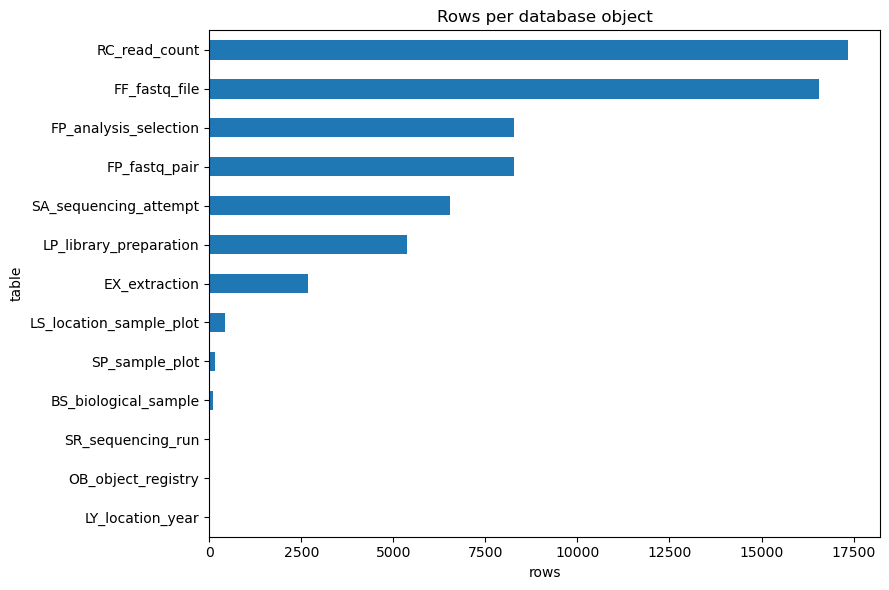

In [37]:
if HAS_MATPLOTLIB:
    ax = DB_entity_summary.set_index("table")["rows"].sort_values().plot(kind="barh", figsize=(9, 6), title="Rows per database object")
    ax.set_xlabel("rows")
    plt.tight_layout()
    plt.show()
else:
    DB_entity_summary.sort_values("rows")


# VALIDATION CHECKS

In [38]:
valid_physical_pair_mask = FP_fastq_pair["FP_forward_path"].notna() & FP_fastq_pair["FP_reverse_path"].notna()
valid_physical_pair_count = int(valid_physical_pair_mask.sum())
unique_physical_pair_count = int(FP_fastq_pair.loc[valid_physical_pair_mask, ["SR_id", "FP_forward_path", "FP_reverse_path"]].drop_duplicates().shape[0])

validation_summary = pd.DataFrame(
    [
        ["SA rows equal metadata_all rows", len(SA_sequencing_attempt), len(metadata_all), len(SA_sequencing_attempt) == len(metadata_all)],
        ["FP rows at least SA rows", len(FP_fastq_pair), len(SA_sequencing_attempt), len(FP_fastq_pair) >= len(SA_sequencing_attempt)],
        ["FP_analysis rows equal FP rows", len(FP_analysis_selection), len(FP_fastq_pair), len(FP_analysis_selection) == len(FP_fastq_pair)],
        ["SA ids unique", SA_sequencing_attempt["SA_id"].nunique(), len(SA_sequencing_attempt), SA_sequencing_attempt["SA_id"].is_unique],
        ["SA duplicate rownames detected", len(SA_duplicate_rownames), FP_control_collision_count, len(SA_duplicate_rownames) == FP_control_collision_count],
        ["SA sample-and-seq-control rows", int((SA_sequencing_attempt["SA_is_sample"] & SA_sequencing_attempt["SA_is_seq_control"]).sum()), len(SA_duplicate_rownames), int((SA_sequencing_attempt["SA_is_sample"] & SA_sequencing_attempt["SA_is_seq_control"]).sum()) == len(SA_duplicate_rownames)],
        ["FP ids unique", FP_fastq_pair["FP_id"].nunique(), len(FP_fastq_pair), FP_fastq_pair["FP_id"].is_unique],
        ["FP physical R1/R2 pairs unique", unique_physical_pair_count, valid_physical_pair_count, unique_physical_pair_count == valid_physical_pair_count],
        ["FP rows tagged with collapsed control metadata", int(FP_fastq_pair["FP_include_control_crushed_amplicon"].sum()), FP_control_collision_count, int(FP_fastq_pair["FP_include_control_crushed_amplicon"].sum()) == FP_control_collision_count],
        ["Collapsed control FP rows dropped", FP_control_collision_dropped_rows, FP_control_collision_count, FP_control_collision_dropped_rows == FP_control_collision_count],
        ["FF ids unique", FF_fastq_file["FF_id"].nunique(), len(FF_fastq_file), FF_fastq_file["FF_id"].is_unique],
        ["SR ids all in path table", int(SR_sequencing_run["SR_in_path_table"].sum()), len(SR_sequencing_run), bool(SR_sequencing_run["SR_in_path_table"].all())],
        ["FP pairs with both read counts", int(FP_fastq_pair["FP_has_read_count"].sum()), len(FP_fastq_pair), bool(FP_fastq_pair["FP_has_read_count"].all())],
    ],
    columns=["check", "observed", "expected_or_total", "passed"],
)
validation_summary


,check,observed,expected_or_total,passed
0,SA rows equal metadata_all rows,6525,6525,True
1,FP rows at least SA rows,8283,6525,True
2,FP_analysis rows equal FP rows,8283,8283,True
3,SA ids unique,6525,6525,True
4,SA duplicate rownames detected,48,48,True
5,SA sample-and-seq-control rows,48,48,True
6,FP ids unique,8283,8283,True
7,FP physical R1/R2 pairs unique,8277,8277,True
8,FP rows tagged with collapsed control metadata,48,48,True
9,Collapsed control FP rows dropped,48,48,True


In [39]:
# Rows that need attention before analysis selection.
FP_attention = FP_analysis_selection[
    ~FP_analysis_selection["FP_include_candidate"].fillna(False)
].copy()

print("Rows needing attention:", len(FP_attention))
FP_attention[[c for c in ["FP_id", "SR_id", "SA_seq_sample_ID", "FP_forward_fq", "FP_reverse_fq", "FP_exclude_reason"] if c in FP_attention.columns]].head(30)


Rows needing attention: 6


,FP_id,SR_id,SA_seq_sample_ID,FP_forward_fq,FP_reverse_fq,FP_exclude_reason
108,FP_SA_seq231107_RISO1_washed_1_T_2021_16S_c_mystery_2021_crushed_amplicon__P01,seq231107_RISO1,washed-1-T-2021-16S-c-mystery,<NA>,<NA>,missing_read_count
1172,FP_SA_seq230526_JRV78_DO_NOT_INCLUDE_2022_crushed_amplicon__P01,seq230526_JRV78,DO-NOT-INCLUDE,<NA>,<NA>,missing_read_count
1185,FP_SA_seq230315_PF2CP_R_210622_s_20E_2022_washed_shotgun__P01,seq230315_PF2CP,R-210622-s-20E,<NA>,<NA>,missing_read_count
1186,FP_SA_seq230315_PF2CP_R_210622_s_16E_2022_washed_shotgun__P01,seq230315_PF2CP,R-210622-s-16E,<NA>,<NA>,missing_read_count
1187,FP_SA_seq230315_PF2CP_R_100622_s_15B_2022_washed_shotgun__P01,seq230315_PF2CP,R-100622-s-15B,<NA>,<NA>,missing_read_count
1188,FP_SA_seq230315_PF2CP_R_100622_s_23B_2022_washed_shotgun__P01,seq230315_PF2CP,R-100622-s-23B,<NA>,<NA>,missing_read_count


# VISUAL AIDS

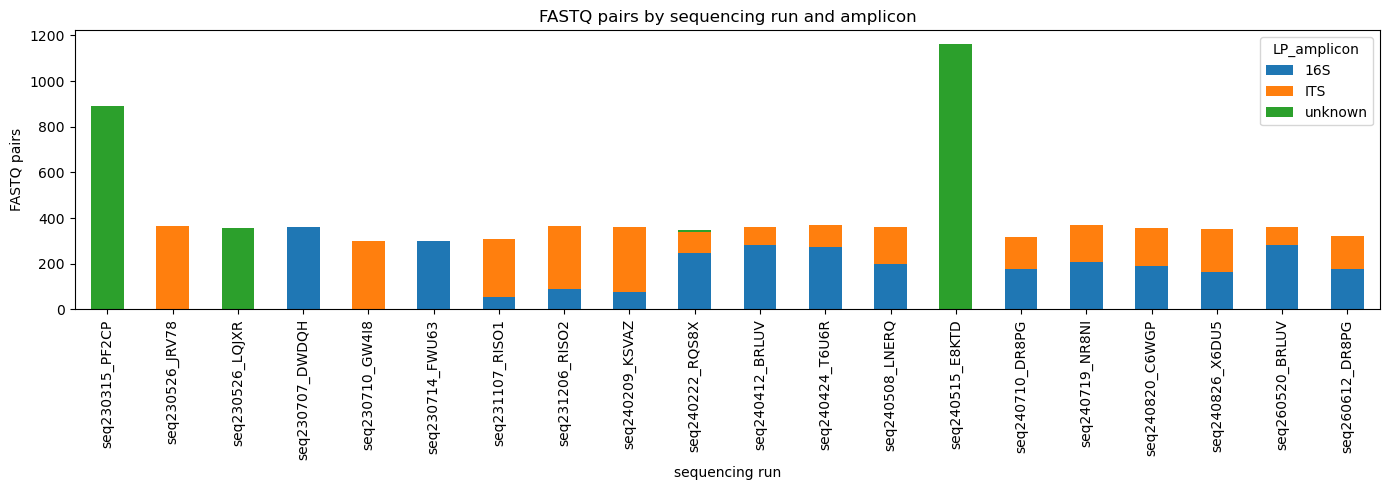

LP_amplicon,16S,ITS,unknown
SR_id,,,
seq230315_PF2CP,0,0,892
seq230526_JRV78,0,364,0
seq230526_LQJXR,0,0,356
seq230707_DWDQH,363,0,0
seq230710_GW4I8,0,298,0
seq230714_FWU63,299,0,0
seq231107_RISO1,53,256,0
seq231206_RISO2,91,273,0
seq240209_KSVAZ,78,283,0


In [40]:
# FASTQ pair count by sequencing run and amplicon.
run_amplicon_counts = pd.crosstab(
    FP_analysis_selection["SR_id"],
    FP_analysis_selection.get("LP_amplicon", pd.Series("unknown", index=FP_analysis_selection.index)).fillna("unknown"),
)

if HAS_MATPLOTLIB:
    ax = run_amplicon_counts.plot(kind="bar", stacked=True, figsize=(14, 5), title="FASTQ pairs by sequencing run and amplicon")
    ax.set_xlabel("sequencing run")
    ax.set_ylabel("FASTQ pairs")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; showing the count table instead.")

run_amplicon_counts


In [41]:
# Rerun overview.
rerun_summary = (
    FP_analysis_selection
    .groupby(["SA_is_rerun", "SR_id", "LP_amplicon"], dropna=False)
    .size()
    .reset_index(name="FP_pairs")
    .sort_values(["SA_is_rerun", "SR_id", "LP_amplicon"])
)
rerun_summary


,SA_is_rerun,SR_id,LP_amplicon,FP_pairs
0,False,seq230315_PF2CP,NaN,892
1,False,seq230526_JRV78,ITS,364
2,False,seq230526_LQJXR,NaN,356
3,False,seq230707_DWDQH,16S,363
4,False,seq230710_GW4I8,ITS,298
5,False,seq230714_FWU63,16S,299
6,False,seq231107_RISO1,16S,53
7,False,seq231107_RISO1,ITS,256
8,False,seq231206_RISO2,16S,91
9,False,seq231206_RISO2,ITS,273


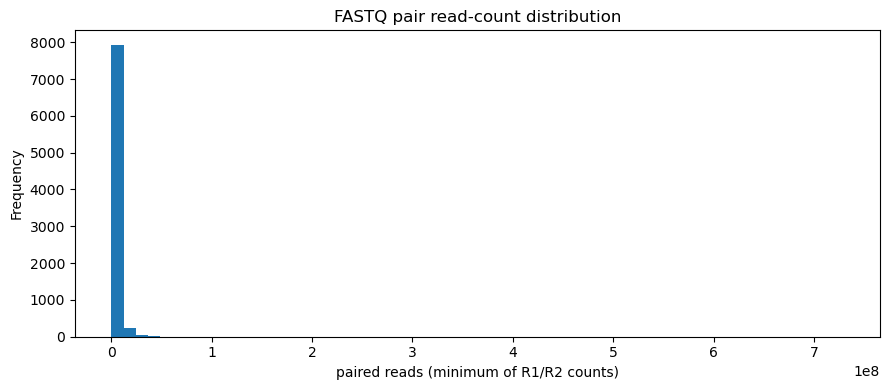

In [42]:
# Read count distribution for analysis candidates.
plot_data = FP_analysis_selection[FP_analysis_selection["FP_pair_reads"].notna()].copy()
if HAS_MATPLOTLIB:
    ax = plot_data["FP_pair_reads"].plot(kind="hist", bins=60, figsize=(9, 4), title="FASTQ pair read-count distribution")
    ax.set_xlabel("paired reads (minimum of R1/R2 counts)")
    plt.tight_layout()
    plt.show()
else:
    plot_data["FP_pair_reads"].describe()


# SAVE DATABASE TABLES

In [43]:
database_output_dir.mkdir(exist_ok=True)
shared_database_output_dir.mkdir(exist_ok=True)

for table_name, table in database_tables.items():
    table.to_csv(database_output_dir / f"{table_name}.csv", index=False)

shared_database_tables = {
    "OB_object_registry": OB_object_registry,
    "LY_location_year": LY_location_year,
    "SP_sample_plot": SP_sample_plot,
    "LS_location_sample_plot": LS_location_sample_plot,
    "BS_biological_sample": BS_biological_sample,
}

for table_name, table in shared_database_tables.items():
    table.to_csv(shared_database_output_dir / f"{table_name}.csv", index=False)

print(f"Saved {len(database_tables)} tables to {database_output_dir}")
print(f"Saved {len(shared_database_tables)} shared DB tables to {shared_database_output_dir}")


Saved 13 tables to /home/lmf/db/MATRIX_METADATA/MICROBIOMICS/NOTEBOOKS/database_tables


# NOTES

Recommended workflow:

1. Keep `rename_scripts.ipynb` responsible for producing `metadata_all.csv`.
2. Keep this notebook responsible for turning `metadata_all.csv` into database-style lookup tables.
3. Use `FP_analysis_selection.csv` as the file where you decide which FASTQ pairs to work with.
4. Add analysis decisions in columns such as `FP_include_candidate`, `FP_exclude_reason`, and later perhaps `FP_use_for_analysis`.
5. If a new concept appears, add a new two-letter object to `OB_object_registry` before adding columns.
